In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

/home/soumyajit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [3]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]
P_ee_err= prob_data["P_ee_err"]

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [4]:
neutrino_flux = pd.read_csv("neutrino_flux.txt", sep="\s+")

In [5]:
L = neutrino_flux['Distance_km'].to_numpy()[:16] # Only Japan reactors
Phi = neutrino_flux['Flux_cm2_s'].to_numpy()[:16] # Only Japan reactors

L_avg = np.sum(L*Phi)/np.sum(Phi)

print(f"The flux-weighted average reactor baseline is L = {L_avg:.2f} km.")

The flux-weighted average reactor baseline is L = 188.43 km.


In [6]:
# In[7] -- correct flux-weighted theoretical probability

# reactor baselines and fluxes
L_reactors = neutrino_flux['Distance_km'].to_numpy()[:16]
Phi = neutrino_flux['Flux_cm2_s'].to_numpy()[:16]

# reference baseline used to define x = L/E
L_ref = L_avg   # or set L_ref = 180.0 if you want to follow the paper literally

def P_ee_vacuum(E, L, dm21, th12, th13, dm31=2.50e-3):
    
    #Three-flavor vacuum survival probability for reactor antineutrinos
    
    dm32 = dm31 - dm21

    E_GeV = E / 1000.0   # convert MeV → GeV

    Delta21 = 1.267 * dm21 * L / E_GeV
    Delta31 = 1.267 * dm31 * L / E_GeV
    Delta32 = 1.267 * dm32 * L / E_GeV

    s12, c12 = np.sin(th12), np.cos(th12)
    s13, c13 = np.sin(th13), np.cos(th13)

    Pee = (
        1
        - 4 * (c12**2 * c13**2) * (s12**2 * c13**2) * np.sin(Delta21)**2
        - 4 * (c12**2 * c13**2) * (s13**2)        * np.sin(Delta31)**2
        - 4 * (s12**2 * c13**2) * (s13**2)        * np.sin(Delta32)**2
    )
    return Pee


def flux_weighted_Pee(x_values, dm21, th12, th13, dm31=2.50e-3):
    
#Flux-weighted theoretical survival probability evaluated at the x-values of the KamLAND bins, where x = L_ref / E.
   
    x_values = np.asarray(x_values)
    Pee_weighted = np.zeros_like(x_values, dtype=float)

    for i, x in enumerate(x_values):
        E = L_ref / x   # MeV, since x is in km/MeV and L_ref is in km

        Pee_reactors = np.array([
            P_ee_vacuum(E, Lr, dm21, th12, th13, dm31)
            for Lr in L_reactors
        ])

        Pee_weighted[i] = np.sum(Phi * Pee_reactors) / np.sum(Phi)

    return Pee_weighted

In [7]:
def flux_weighted_binned_Pee(x_centers, dx, dm21, th12, th13, dm31=2.50e-3, n_sub=20):
    x_centers = np.asarray(x_centers)
    Pee_binned = np.zeros_like(x_centers, dtype=float)

    for i, xc in enumerate(x_centers):
        x_samples = np.linspace(xc - dx/2, xc + dx/2, n_sub)

        Pee_samples = []
        for x in x_samples:
            E = L_ref / x
            Pee_reactors = np.array([
                P_ee_vacuum(E, Lr, dm21, th12, th13, dm31)
                for Lr in L_reactors
            ])
            Pee_samples.append(np.sum(Phi * Pee_reactors) / np.sum(Phi))

        Pee_binned[i] = np.mean(Pee_samples)

    return Pee_binned

In [8]:
x = prob_data["x (L/E)"].to_numpy()
P_data = prob_data["P_ee"].to_numpy()
P_err = prob_data["P_ee_err"].to_numpy()

In [9]:
def chi2_vacuum(dm21, th12, th13):
    P_th = flux_weighted_Pee(x, dm21, th12, th13)
    return np.sum(((P_data - P_th) / P_err)**2)

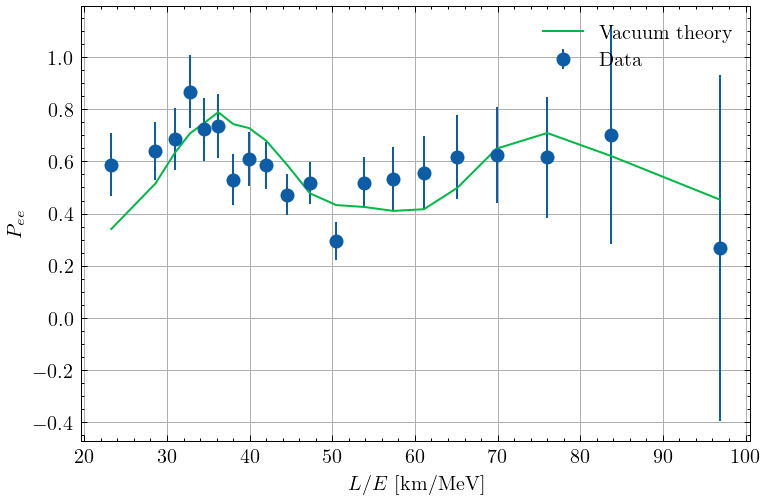

In [10]:
# theory prediction at bin centres
dm21_test = 7.5e-5
th12_test = 0.59
th13_test = 0.15

P_th = flux_weighted_Pee(x, dm21_test, th12_test, th13_test)

plt.errorbar(x, P_data, yerr=P_err, fmt='o', label='Data')
plt.plot(x, P_th, label='Vacuum theory')
plt.xlabel(r'$L/E$ [km/MeV]')
plt.ylabel(r'$P_{ee}$')
plt.legend()
plt.grid()
plt.show()

In [12]:
dx = np.median(np.diff(x))
pp= flux_weighted_Pee(x, dm21_test, th12_test, th13_test)
pp

array([0.34082527, 0.51523146, 0.63236584, 0.70741424, 0.74726655,
       0.78894361, 0.74311598, 0.72793421, 0.67922445, 0.58810621,
       0.47723215, 0.43251379, 0.42525633, 0.41003957, 0.41663623,
       0.49896563, 0.64908261, 0.70904355, 0.62124414, 0.45311439])

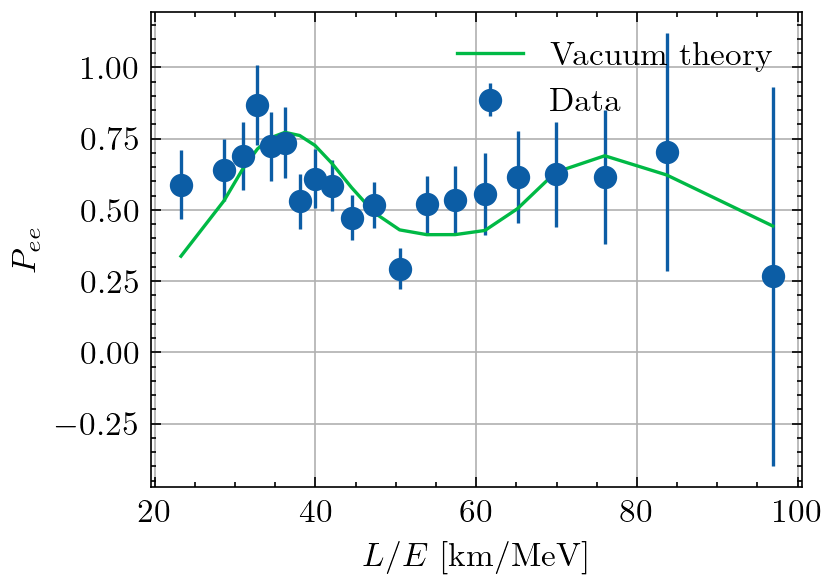

In [37]:
plt.errorbar(x, P_data, yerr=P_err, fmt='o', label='Data')
plt.plot(x, pp, label='Vacuum theory')
plt.xlabel(r'$L/E$ [km/MeV]')
plt.ylabel(r'$P_{ee}$')
plt.legend()
plt.grid()
plt.show()

In [14]:
def loglike_cube(cube):
    dm21 = 1e-5 + cube[0] * (15e-5 - 1e-5)
    th12 = cube[1] * 1.0
    th13 = cube[2] * 1.0

    P_th = flux_weighted_binned_Pee(x, dx, dm21_test, th12_test, th13_test)
    chi2 = np.sum(((P_data - P_th) / P_err)**2)

    return -0.5 * chi2

In [26]:
dx = np.median(np.diff(x))

In [13]:
def chi2_vacuum(params):

    dm21, th12, th13 = params
    P_th = flux_weighted_binned_Pee(x, dx, dm21, th12, th13)

    chi2 = np.sum(((P_data - P_th)/P_err)**2)

    return chi2

In [16]:
from scipy.optimize import minimize

initial = [7.5e-5, 0.6, 0.15]

res = minimize(chi2_vacuum, initial)

dm21_best, theta12_best, theta13_best = res.x
print(res.x)

[8.36174078e-05 5.16319549e-01 2.58996172e-01]


In [25]:
dm21_grid = np.linspace(5e-5, 12e-5, 60)
th12_grid = np.linspace(0.4, 0.9, 60)

chi2_map = np.zeros((len(th12_grid), len(dm21_grid)))

for j, th12 in enumerate(th12_grid):
    for i, dm21 in enumerate(dm21_grid):
        chi2_map[j, i] = chi2_vacuum([dm21, th12, 0.15])

KeyboardInterrupt: 

In [43]:
chi2_min = np.min(chi2_map)
delta_chi2 = chi2_map - chi2_min

In [44]:
levels = [2.30, 6.18]

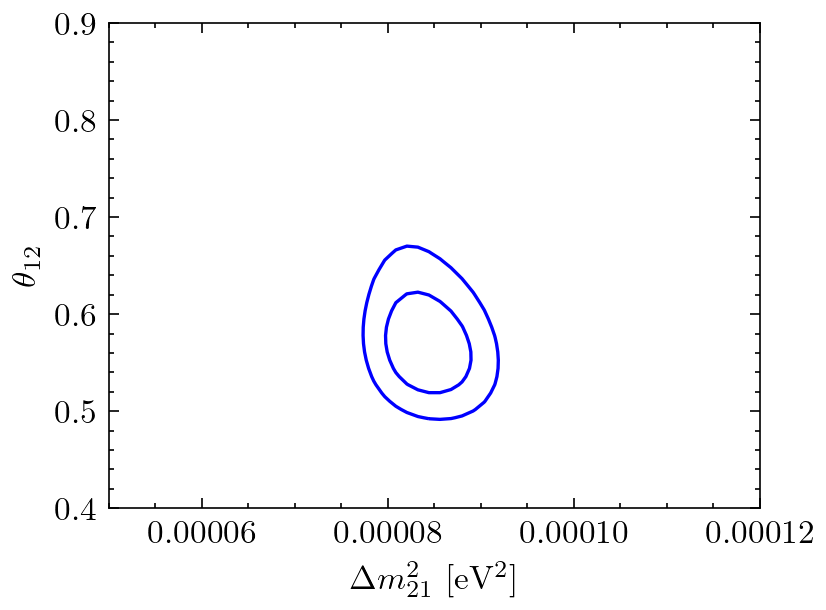

In [45]:
X, Y = np.meshgrid(dm21_grid,th12_grid)

plt.contour(
    X,
    Y,
    delta_chi2,
    levels=levels,
    colors=['blue','blue']
)
plt.xlabel(r'$\Delta m^2_{21}$ [eV$^2$]')
plt.ylabel(r'$\theta_{12}$')
plt.show()

In [28]:
param_names = [r'$\Delta m^2_{21}\,[10^{-5}\,\mathrm{eV}^2]$', r'$\theta_{12}$', r'$\theta_{13}$']

import scipy.stats

def my_prior_transform(cube):
    params = cube.copy()

    # dm21 in [1,15] x 1e-5 eV^2
    params[0] = (cube[0] * (15 - 1) + 1) * 1e-5

    # theta12 in [0,1]
    params[1] = cube[1]

    # theta13 in [0,1]
    params[2] = cube[2]

    return params

In [29]:
from numpy import log

def my_likelihood(params):
    dm21, theta12, theta13 = params

    P_th = flux_weighted_binned_Pee(x, dx, dm21, theta12, theta13)

    chi2 = np.sum(((P_data - P_th) / P_err)**2)

    return -0.5 * chi2

In [30]:
print(my_likelihood([7.5e-5, 0.59, 0.15]))
print(my_likelihood([8.5e-5, 0.59, 0.15]))
print(my_likelihood([7.5e-5, 0.75, 0.15]))

-11.747187228140778
-5.958960619402554
-15.796744000097108


In [31]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [32]:
result = sampler.run(show_status=True, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
Z=-15.7(1.79%) | Like=-12.73..-5.27 [-13.4366..-12.3113] | it/evals=1299/8013 eff=17.0629% N=400 

KeyboardInterrupt: 

In [88]:
samples = result['samples'].copy()
samples[:, 0] *= 1e5

In [89]:
param_names_plot = [
    r'$\Delta m^2_{21}\times 10^{5}\;[\mathrm{eV}^2]$',
    r'$\theta_{12}$',
    r'$\theta_{13}$'
]

In [90]:
result_plot = result.copy()
result_plot['samples'] = samples

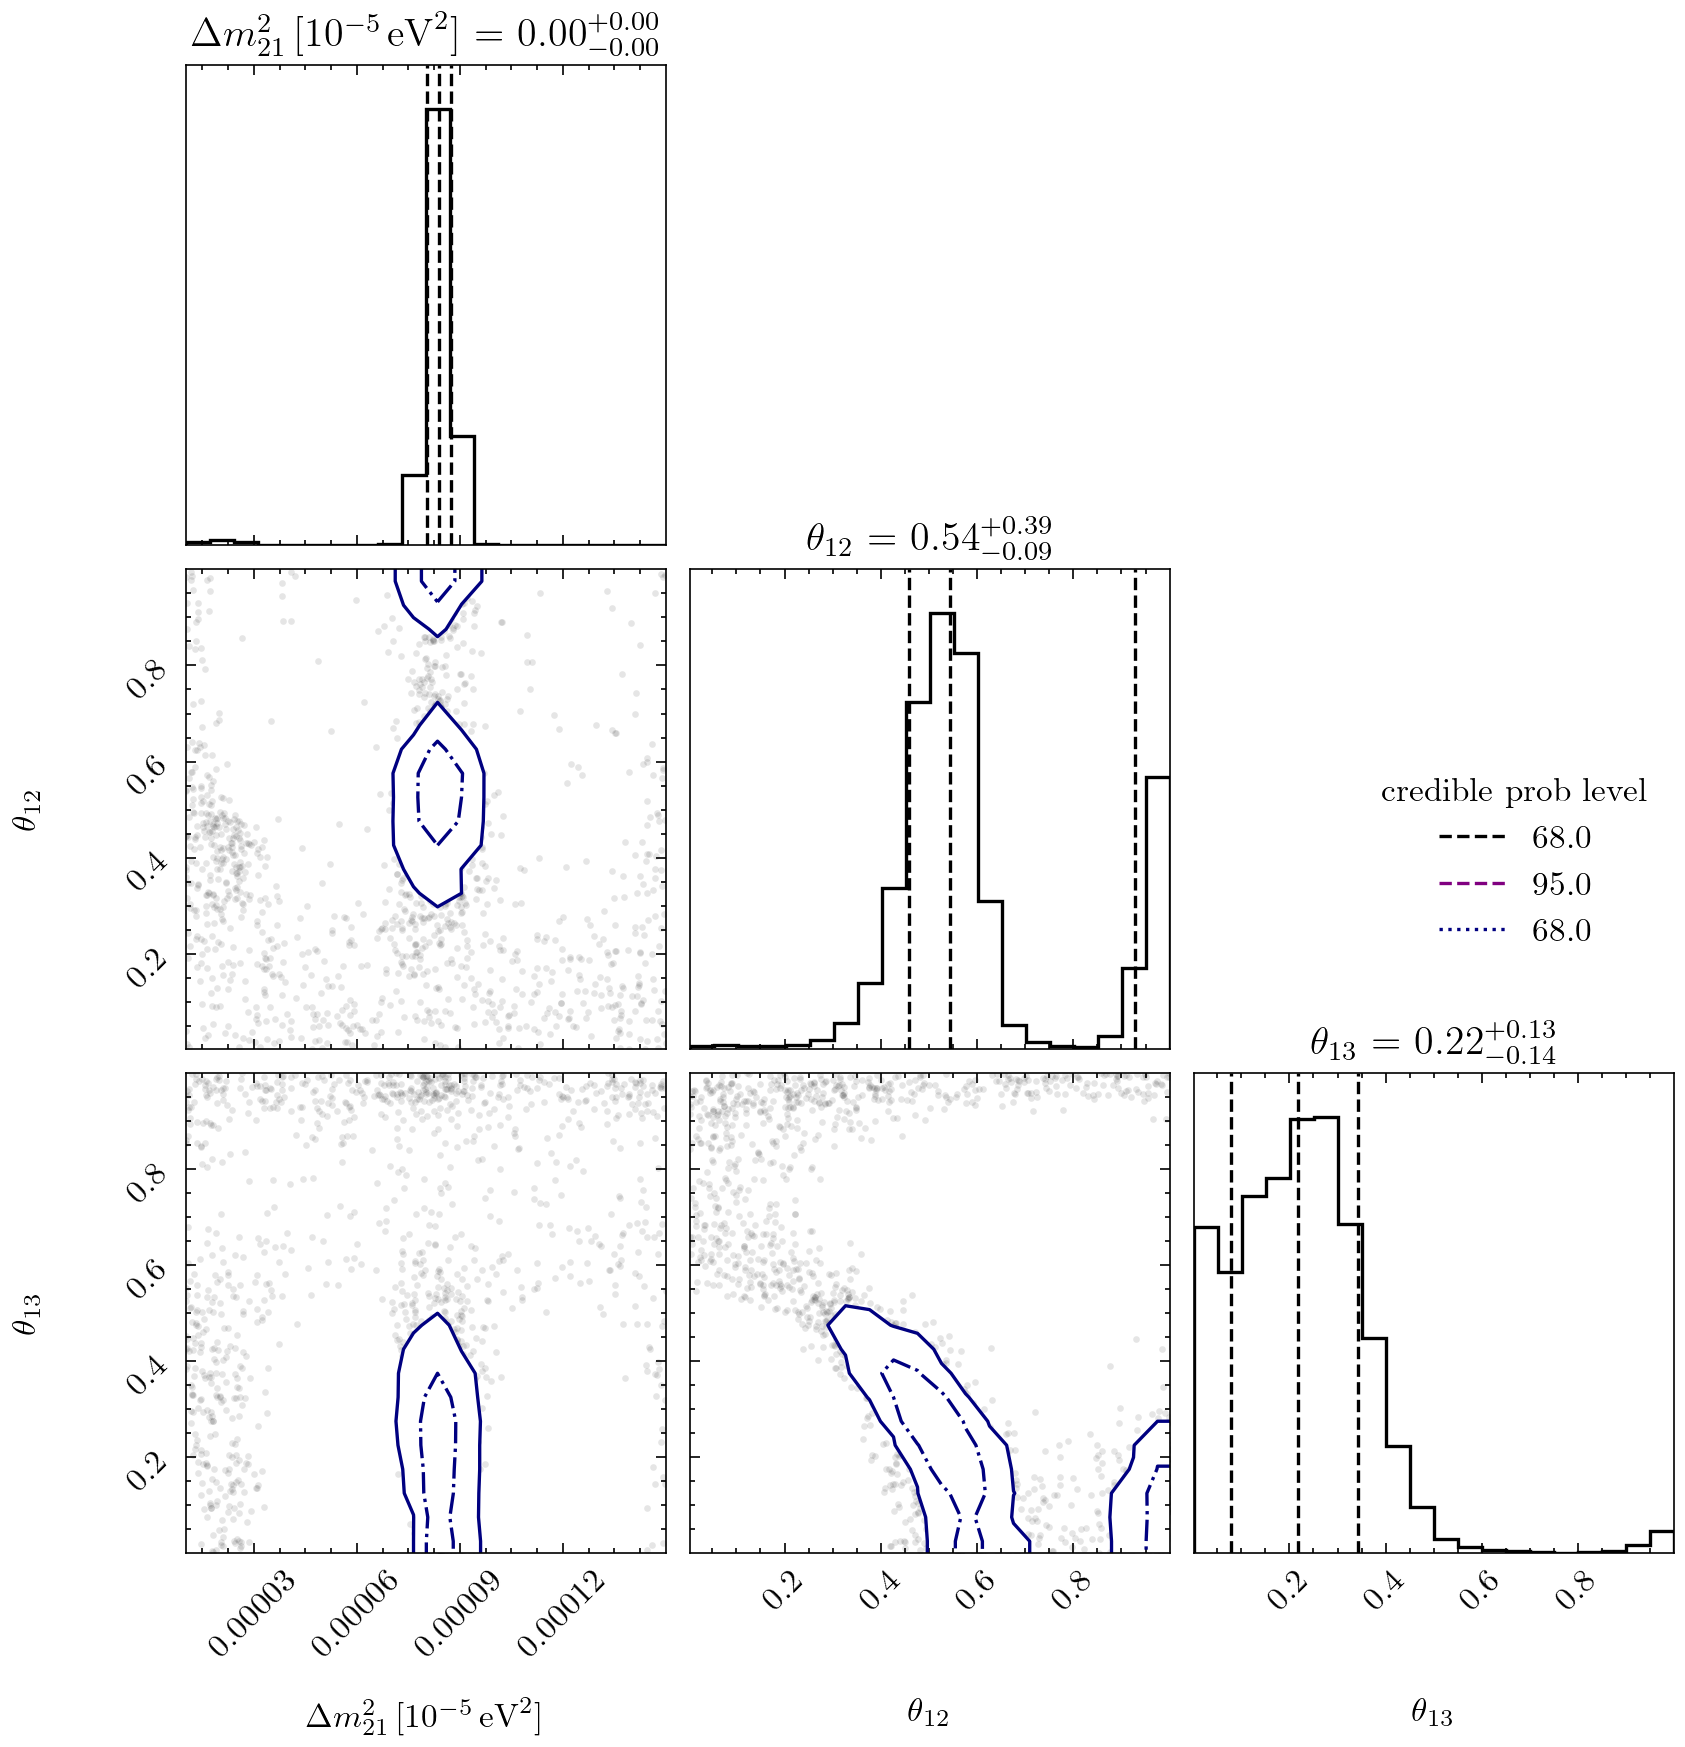

In [91]:
fig = cornerplot(
    result_plot,
    paramnames=param_names_plot,
    plot_datapoints=True,
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84],
    color='black'
)
plt.show()

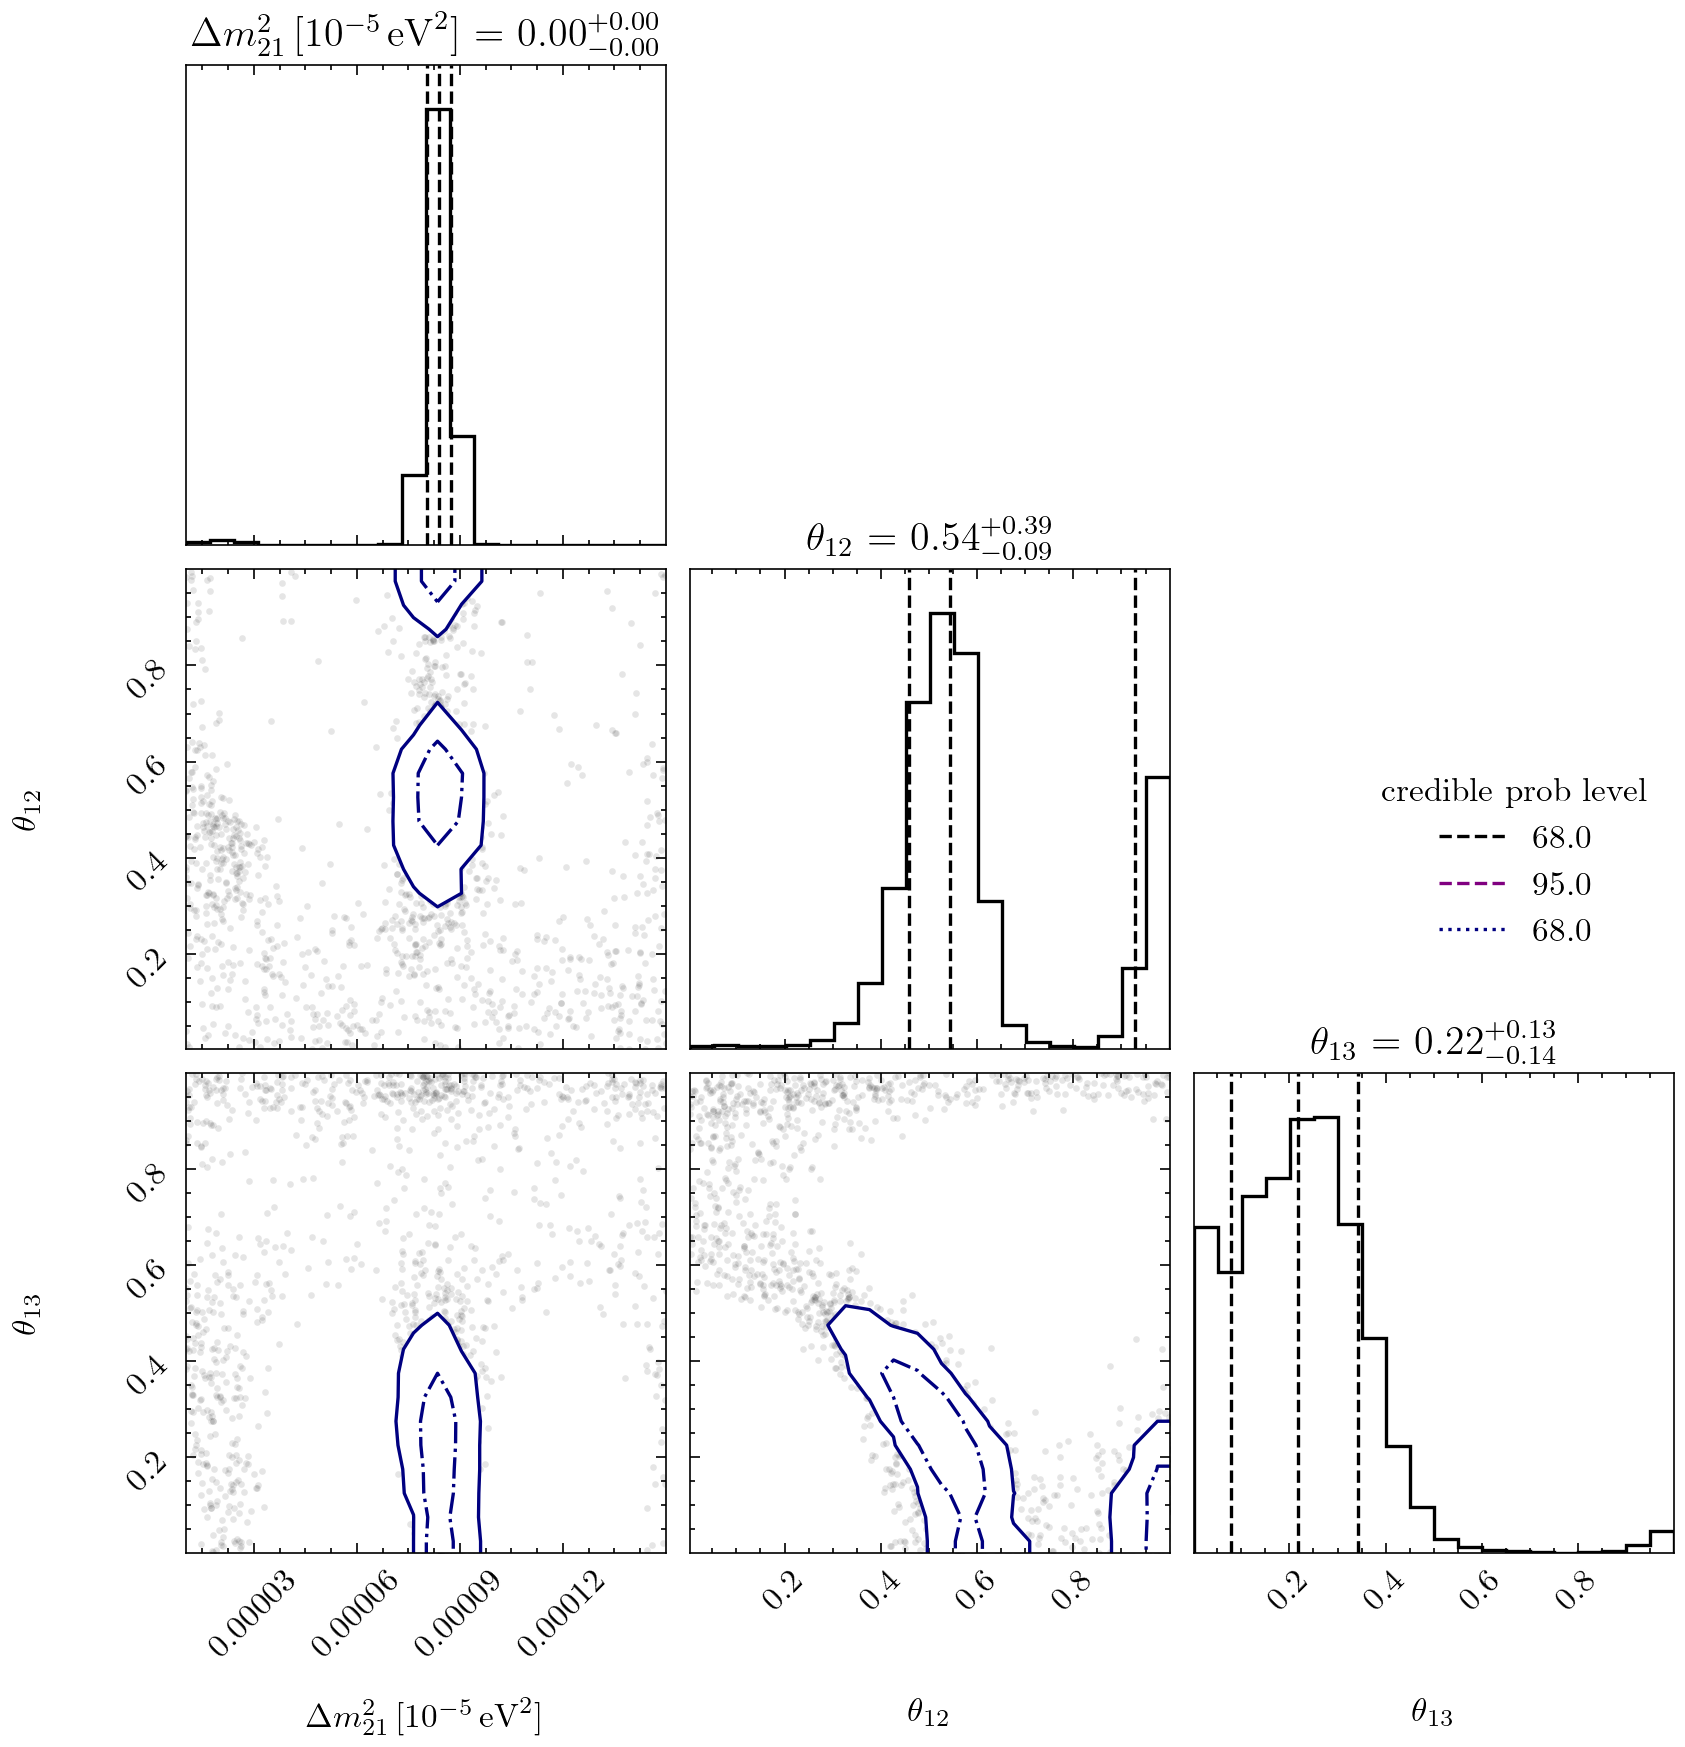

In [87]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                # show_titles=False,
                color='black',
                # plot_contour_labels=False
               );

# plt.tight_layout()
# plt.legend().remove()

plt.show()